In [1]:
#load required packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#link to dataset: 
#https://open.toronto.ca/dataset/police-annual-statistical-report-tickets-issued/

#import data (skip first row because the headers start in the second row of the dataset)
df = pd.read_csv("C:/Users/ziral/Documents/MSc_PhD Nutritional Science/Data Science Institute Certificate/Assignments/visualization/02_activities/assignments/participation/Tickets_Issued.csv")

#view first few rows
df.head()

,_id,INDEX_,OFFENCE_YEAR,DIVISION,TICKET_TYPE,OFFENCE_CATEGORY,AGE_GROUP,HOOD_158,NEIGHBOURHOOD_158,TICKET_COUNT
0,1,1,2014,D11,Prov Offence Notice - Part I (Pot) ...,Aggressive Driving,Adult,89,Runnymede-Bloor West Village,83
1,2,2,2014,D11,Prov Offence Notice - Part I (Pot) ...,Distracted Driving,Adult,NSA,NSA,150
2,3,3,2014,D11,Prov Offence Notice - Part I (Pot) ...,Aggressive Driving,Adult,111,Rockcliffe-Smythe,2
3,4,4,2014,D11,Prov Offence Notice - Part I (Pot) ...,Other HTA,Adult,NSA,NSA,563
4,5,5,2014,D11,Prov Offence Notice - Part I (Pot) ...,All CAIA,Adult,86,Roncesvalles,84


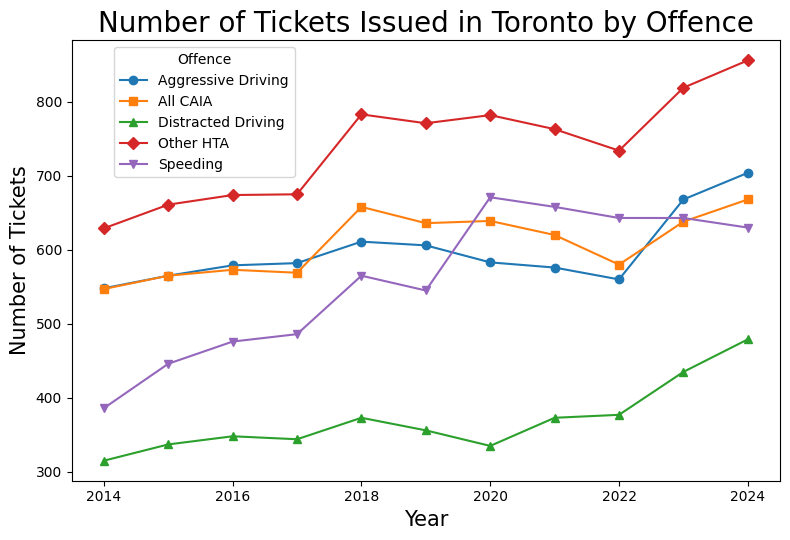

In [6]:
#count tickets by year and offence category
yearly_counts = (
    df.groupby(["OFFENCE_YEAR", "OFFENCE_CATEGORY"])["_id"]
      .count()
      .reset_index(name="count")
)

#counts by each offence category and year
categories = yearly_counts["OFFENCE_CATEGORY"].unique()

#set a different marker style for each type of offence (to help improve accessibility for individuals with colour blindness)
markers = ["o", "s", "^", "D", "v"]

#set figure size
plt.figure(figsize=(8, 5.5))

#loop through all offence categories and for each, plot the count of the offences by year 
for i, category in enumerate(categories):
    subset = yearly_counts[yearly_counts["OFFENCE_CATEGORY"] == category]
    
    plt.plot(
        subset["OFFENCE_YEAR"],
        subset["count"],
        marker=markers[i % len(markers)],
        label=category
    )

#add main plot title and axis titles
plt.title("Number of Tickets Issued in Toronto by Offence", fontsize=20)
plt.xlabel("Year", fontsize=15)
plt.ylabel("Number of Tickets", fontsize=15)

#add a plot legend showing the colour of each offence in the upper left corner of the graph
plt.legend(title="Offence", bbox_to_anchor=(0.05, 1), loc="upper left")
plt.tight_layout()

#save figure
path = 'C:/Users/ziral/Documents/MSc_PhD Nutritional Science/Data Science Institute Certificate/Assignments/visualization/02_activities/assignments'
filename = '/assignment_3_viz1.png'
plt.savefig(path+filename, dpi=300)

plt.show()
